# MITgcm ECCOv4 Example

This Jupyter notebook demonstrates how to use [xarray](https://docs.xarray.dev) and [xgcm](https://xgcm.readthedocs.io) to analyze data from the [ECCO v4r4](https://ecco-group.org/products-ECCO-V4r4.htm) ocean state estimate.

The data are a 12-month (2010) subset of the ECCOv4r4 ocean state estimate on its native Lat-Lon-Cap 90 (LLC90) grid, hosted on [Zenodo](https://doi.org/10.5281/zenodo.21051424) under a CC0 (public-domain) license. These files are byte-identical to the corresponding NASA [PO.DAAC ECCOv4r4](https://podaac.jpl.nasa.gov/ECCO) native-grid monthly-mean granules; please cite ECCO/PO.DAAC if you use the data in published work (see the [ECCOv4r4 product page](https://ecco-group.org/products-ECCO-V4r4.htm)).

First we import our standard python packages:

In [1]:
import xarray as xr
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

## Load the data

The notebook is self-contained: the cell below downloads the ECCOv4r4 files it needs directly from Zenodo into a local `eccov4r4_data/` folder (skipping any file already present). We grab four field groups for the 2010 calendar year:

- the grid geometry (`GRID_GEOMETRY`, always needed),
- monthly-mean potential temperature and salinity (`OCEAN_TEMPERATURE_SALINITY`, has `THETA`, `SALT`),
- monthly-mean 3-D advective and diffusive temperature fluxes (`OCEAN_3D_TEMPERATURE_FLUX`, has `ADVx_TH`, `ADVy_TH`, `DFxE_TH`, `DFyE_TH`, ...),
- monthly-mean ocean-and-ice surface heat flux (`OCEAN_AND_ICE_SURFACE_HEAT_FLUX`, has `TFLUX`).

The download is roughly 1.1 GB and only happens the first time you run the notebook.

In [2]:
# download the data (only the first time)
import urllib.request
import shutil
from pathlib import Path

record = "21051920"
base = f"https://zenodo.org/records/{record}/files/"
path = Path("eccov4r4_data/")
path.mkdir(parents=True, exist_ok=True)

# the grid file plus three monthly field groups, for each month of 2010
groups = [
    "OCEAN_TEMPERATURE_SALINITY_mon_mean_2010-{mm}_ECCO_V4r4_native_llc0090.nc",
    "OCEAN_3D_TEMPERATURE_FLUX_mon_mean_2010-{mm}_ECCO_V4r4_native_llc0090.nc",
    "OCEAN_AND_ICE_SURFACE_HEAT_FLUX_mon_mean_2010-{mm}_ECCO_V4r4_native_llc0090.nc",
]
filenames = ["GRID_GEOMETRY_ECCO_V4r4_native_llc0090.nc"]
for template in groups:
    for month in range(1, 13):
        filenames.append(template.format(mm=f"{month:02d}"))

for name in filenames:
    dest = path / name
    if not dest.exists():
        url = base + name + "?download=1"
        tmp = dest.with_suffix(dest.suffix + ".part")
        try:
            with urllib.request.urlopen(url) as response, open(tmp, "wb") as out_file:
                shutil.copyfileobj(response, out_file)
            tmp.replace(dest)
        except BaseException:
            tmp.unlink(missing_ok=True)
            raise

Now we open the monthly files for each field group (concatenating along `time`) and merge in the grid geometry, so that the coordinates and grid metrics (`XC`, `YC`, `rA`, `hFacC`, `Z`, `Depth`, ...) live alongside the data variables on a single `Dataset`.

The type of object returned is an [Xarray dataset](https://docs.xarray.dev/en/stable/generated/xarray.Dataset.html).

In [3]:
def open_group(prefix):
    files = sorted(path.glob(prefix + "_mon_mean_2010-*_ECCO_V4r4_native_llc0090.nc"))
    return xr.open_mfdataset(files, combine="by_coords")

theta_salt = open_group("OCEAN_TEMPERATURE_SALINITY")
temp_flux  = open_group("OCEAN_3D_TEMPERATURE_FLUX")
surf_flux  = open_group("OCEAN_AND_ICE_SURFACE_HEAT_FLUX")
grid_geom  = xr.open_dataset(path / "GRID_GEOMETRY_ECCO_V4r4_native_llc0090.nc")

ds = xr.merge([theta_salt, temp_flux, surf_flux, grid_geom], compat="override")
ds

<xarray.Dataset> Size: 2GB
Dimensions:    (time: 12, k: 50, tile: 13, j: 90, i: 90, i_g: 90, j_g: 90,
                k_u: 50, k_l: 50, k_p1: 51, nv: 2, nb: 4)
Coordinates: (12/22)
  * time       (time) datetime64[ns] 96B 2010-01-16T12:00:00 ... 2010-12-16T1...
  * k          (k) int32 200B 0 1 2 3 4 5 6 7 8 9 ... 41 42 43 44 45 46 47 48 49
    Z          (k) float32 200B dask.array<chunksize=(50,), meta=np.ndarray>
  * tile       (tile) int32 52B 0 1 2 3 4 5 6 7 8 9 10 11 12
  * j          (j) int32 360B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
  * i          (i) int32 360B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
    ...         ...
  * k_p1       (k_p1) int32 204B 0 1 2 3 4 5 6 7 8 ... 43 44 45 46 47 48 49 50
    Zp1        (k_p1) float32 204B dask.array<chunksize=(51,), meta=np.ndarray>
    time_bnds  (time, nv) datetime64[ns] 192B dask.array<chunksize=(1, 2), meta=np.ndarray>
    Z_bnds     (k, nv) float32 400B dask.array<chunksize=(50, 2), meta=np.ndarray>
    XC_bnds    (tile, j, i, nb) float32 2MB dask.array<chunksize=(13, 90, 90, 4), meta=np.ndarray>
    YC_bnds    (tile, j, i, nb) float32 2MB dask.array<chunksize=(13, 90, 90, 4), meta=np.ndarray>
Dimensions without coordinates: nv, nb
Data variables: (12/42)
    THETA      (time, k, tile, j, i) float32 253MB dask.array<chunksize=(1, 25, 7, 45, 45), meta=np.ndarray>
    SALT       (time, k, tile, j, i) float32 253MB dask.array<chunksize=(1, 25, 7, 45, 45), meta=np.ndarray>
    ADVx_TH    (time, k, tile, j, i_g) float32 253MB dask.array<chunksize=(1, 25, 7, 45, 45), meta=np.ndarray>
    DFxE_TH    (time, k, tile, j, i_g) float32 253MB dask.array<chunksize=(1, 25, 7, 45, 45), meta=np.ndarray>
    ADVy_TH    (time, k, tile, j_g, i) float32 253MB dask.array<chunksize=(1, 25, 7, 45, 45), meta=np.ndarray>
    DFyE_TH    (time, k, tile, j_g, i) float32 253MB dask.array<chunksize=(1, 25, 7, 45, 45), meta=np.ndarray>
    ...         ...
    hFacC      (k, tile, j, i) float32 21MB ...
    hFacW      (k, tile, j, i_g) float32 21MB ...
    hFacS      (k, tile, j_g, i) float32 21MB ...
    maskC      (k, tile, j, i) bool 5MB ...
    maskW      (k, tile, j, i_g) bool 5MB ...
    maskS      (k, tile, j_g, i) bool 5MB ...
Attributes: (12/62)
    acknowledgement:                 This research was carried out by the Jet...
    author:                          Ian Fenty and Ou Wang
    cdm_data_type:                   Grid
    comment:                         Fields provided on the curvilinear lat-l...
    Conventions:                     CF-1.8, ACDD-1.3
    coordinates_comment:             Note: the global 'coordinates' attribute...
    ...                              ...
    time_coverage_duration:          P1M
    time_coverage_end:               2010-02-01T00:00:00
    time_coverage_resolution:        P1M
    time_coverage_start:             2010-01-01T00:00:00
    title:                           ECCO Ocean Temperature and Salinity - Mo...
    uuid:                            f4291248-4181-11eb-82cd-0cc47a3f446d

Note that no data has actually been downloaded into memory yet. Xarray uses the approach of _lazy evaluation_, in which loading of data and execution of computations is delayed as long as possible (i.e. until data is actually needed for a plot). The data are represented symbolically as [dask arrays](https://docs.dask.org/en/latest/array.html). For example:

    THETA      (time, k, tile, j, i) float32 dask.array<chunksize=(1, 50, 13, 90, 90)>

The full array spans all 12 months, 50 vertical levels, and the 13 LLC tiles, but each monthly file forms one chunk — the minimum amount of data we read at one time.

## Visualizing Data

### A Direct Plot

Let's try to visualize something simple: the `Depth` variable. Here is how the data are stored:

    Depth      (tile, j, i) float32 dask.array<chunksize=(13, 90, 90)>

Although depth is a 2D field, there is an extra dimension (`tile`) corresponding to the LLC tile (face) number. Let's use xarray's built-in plotting functions to plot each tile individually.

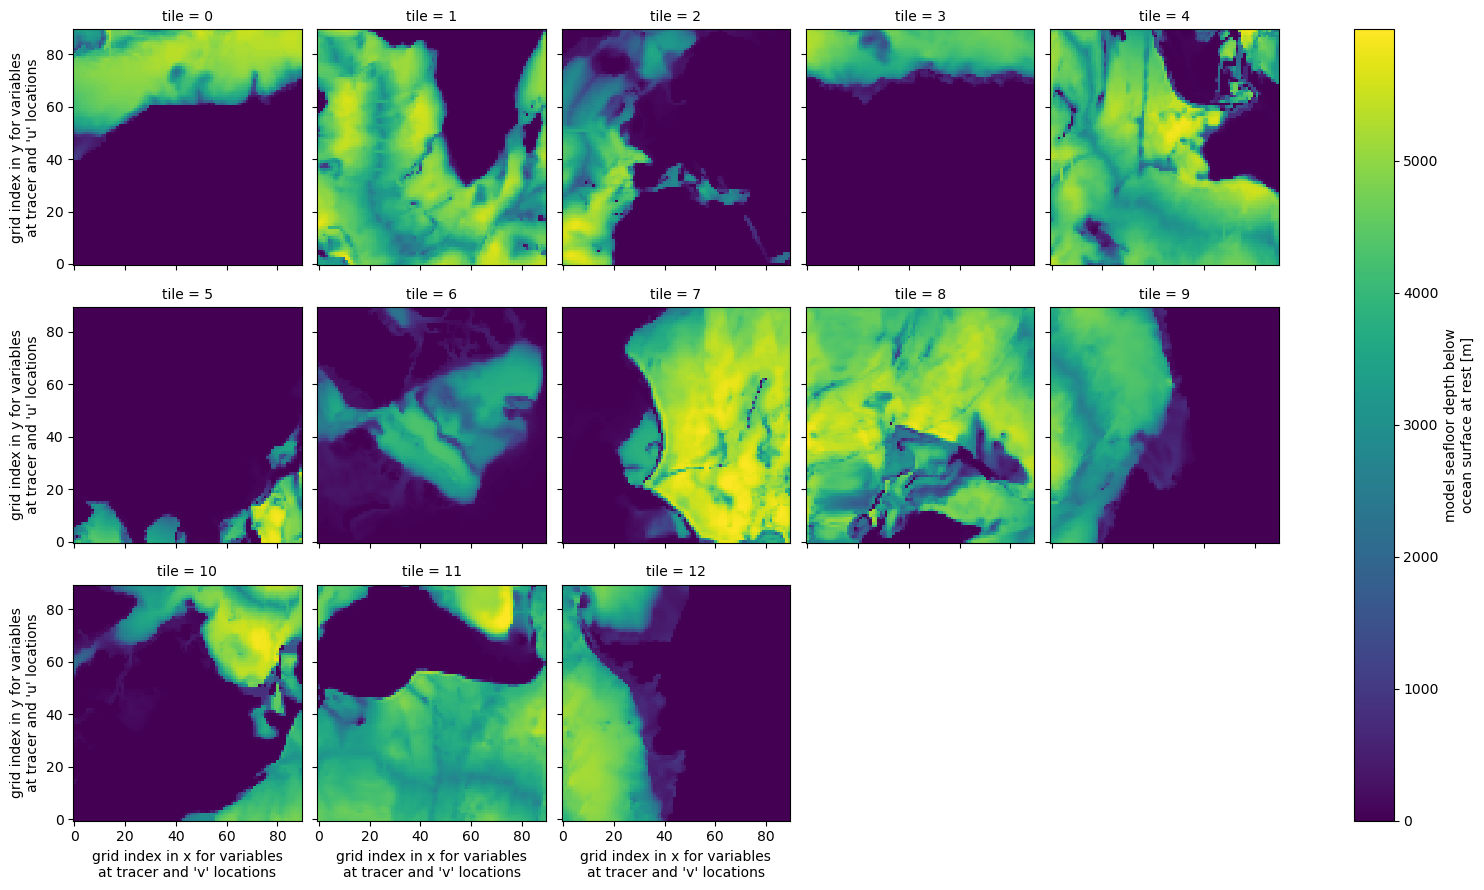

In [4]:
ds.Depth.plot(col='tile', col_wrap=5)

This view is not the most useful. It reflects how the data are arranged logically, rather than geographically.

### A Pretty Map

To make plotting easier, we can define a quick function to plot the data in a more geographically friendly way. It uses [pyresample](https://pyresample.readthedocs.io) to interpolate the LLC tiles onto a regular lon/lat grid.

In [5]:
from matplotlib import pyplot as plt
import cartopy as cart
import pyresample

class LLCMapper:

    def __init__(self, ds, dx=0.25, dy=0.25):
        # Extract LLC 2D coordinates
        lons_1d = ds.XC.values.ravel()
        lats_1d = ds.YC.values.ravel()

        # Define original grid
        self.orig_grid = pyresample.geometry.SwathDefinition(lons=lons_1d, lats=lats_1d)

        # Longitudes latitudes to which we will we interpolate
        lon_tmp = np.arange(-180, 180, dx) + dx/2
        lat_tmp = np.arange(-90, 90, dy) + dy/2

        # Define the lat lon points of the two parts.
        self.new_grid_lon, self.new_grid_lat = np.meshgrid(lon_tmp, lat_tmp)
        self.new_grid  = pyresample.geometry.GridDefinition(lons=self.new_grid_lon,
                                                            lats=self.new_grid_lat)

    def __call__(self, da, ax=None, projection=cart.crs.Robinson(), lon_0=-60, **plt_kwargs):

        assert set(da.dims) == set(['tile', 'j', 'i']), "da must have dimensions ['tile', 'j', 'i']"

        if ax is None:
            fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={'projection': projection})
        else:
            m = plt.axes(projection=projection)

        field = pyresample.kd_tree.resample_nearest(self.orig_grid, da.values,
                                                    self.new_grid,
                                                    radius_of_influence=100000,
                                                    fill_value=None)

        vmax = plt_kwargs.pop('vmax', np.nanmax(field))
        vmin = plt_kwargs.pop('vmin', np.nanmin(field))


        x,y = self.new_grid_lon, self.new_grid_lat

        # Find index where data is splitted for mapping
        split_lon_idx = round(x.shape[1]/(360/(lon_0 if lon_0>0 else lon_0+360)))


        p = ax.pcolormesh(x[:,:split_lon_idx], y[:,:split_lon_idx], field[:,:split_lon_idx],
                         vmax=vmax, vmin=vmin, transform=cart.crs.PlateCarree(), zorder=1, **plt_kwargs)
        p = ax.pcolormesh(x[:,split_lon_idx:], y[:,split_lon_idx:], field[:,split_lon_idx:],
                         vmax=vmax, vmin=vmin, transform=cart.crs.PlateCarree(), zorder=2, **plt_kwargs)

        ax.add_feature(cart.feature.LAND, facecolor='0.5', zorder=3)
        label = ''
        if da.name is not None:
            label = da.name
        if 'units' in da.attrs:
            label += ' [%s]' % da.attrs['units']
        cb = plt.colorbar(p, shrink=0.4, label=label)
        return ax

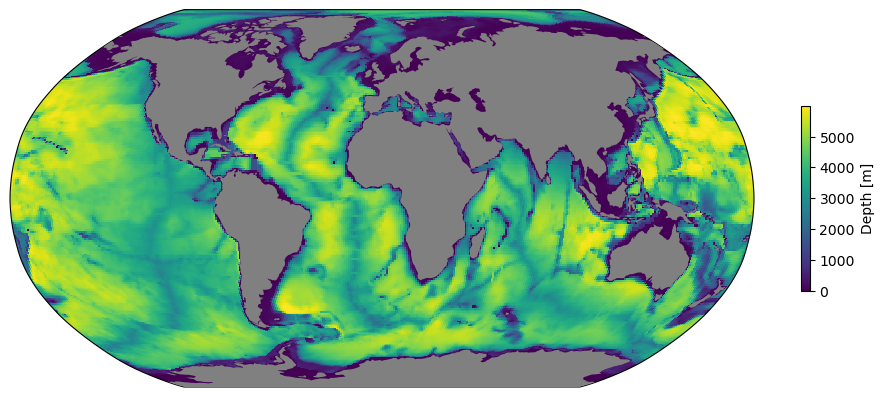

In [6]:
mapper = LLCMapper(ds)
mapper(ds.Depth);

We can use this with any 2D cell-centered LLC variable.

## Selecting data

The entire dataset is contained in a single `xarray.Dataset` object. How do we find and view specific pieces of data? This is handled by Xarray's [indexing and selecting functions](https://docs.xarray.dev/en/stable/user-guide/indexing.html). To get the SST from July 2010, we select the surface level (`k=0`) and the nearest time:

In [7]:
sst = ds.THETA.sel(time='2010-07-15', method='nearest').isel(k=0)
sst

<xarray.DataArray 'THETA' (tile: 13, j: 90, i: 90)> Size: 421kB
dask.array<getitem, shape=(13, 90, 90), dtype=float32, chunksize=(7, 45, 45), chunktype=numpy.ndarray>
Coordinates:
  * tile     (tile) int32 52B 0 1 2 3 4 5 6 7 8 9 10 11 12
  * j        (j) int32 360B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
  * i        (i) int32 360B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
    XC       (tile, j, i) float32 421kB dask.array<chunksize=(13, 90, 90), meta=np.ndarray>
    YC       (tile, j, i) float32 421kB dask.array<chunksize=(13, 90, 90), meta=np.ndarray>
    k        int32 4B 0
    time     datetime64[ns] 8B 2010-07-16T12:00:00
    Z        float32 4B dask.array<chunksize=(), meta=np.ndarray>
Attributes:
    long_name:              Potential temperature 
    units:                  degree_C
    coverage_content_type:  modelResult
    standard_name:          sea_water_potential_temperature
    comment:                Sea water potential temperature is the temperatur...
    valid_min:              -2.2909388542175293
    valid_max:              36.032955169677734

Still no data has actually been downloaded. That doesn't happen until we call `.load()` explicitly or try to make a plot.

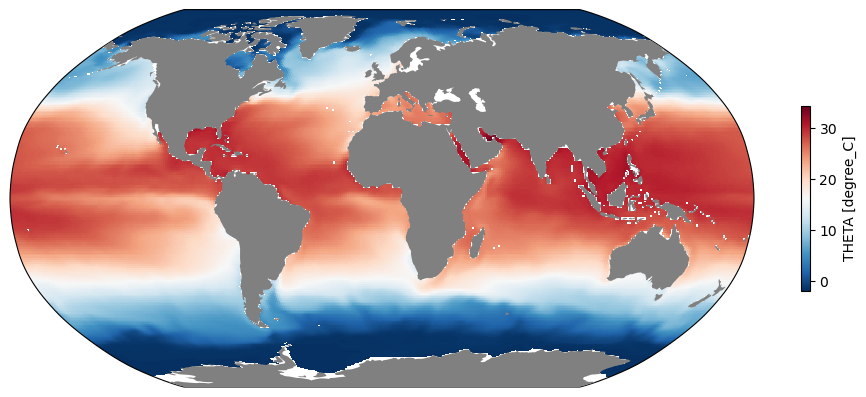

In [8]:
mapper(sst, cmap='RdBu_r');

## Do some Calculations

Now let's start doing something besides just plotting the existing data. For example, let's calculate the 2010 annual-mean SST.

In [9]:
mean_sst = ds.THETA.isel(k=0).mean(dim='time')
mean_sst

<xarray.DataArray 'THETA' (tile: 13, j: 90, i: 90)> Size: 421kB
dask.array<mean_agg-aggregate, shape=(13, 90, 90), dtype=float32, chunksize=(7, 45, 45), chunktype=numpy.ndarray>
Coordinates:
  * tile     (tile) int32 52B 0 1 2 3 4 5 6 7 8 9 10 11 12
  * j        (j) int32 360B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
  * i        (i) int32 360B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
    XC       (tile, j, i) float32 421kB dask.array<chunksize=(13, 90, 90), meta=np.ndarray>
    YC       (tile, j, i) float32 421kB dask.array<chunksize=(13, 90, 90), meta=np.ndarray>
    k        int32 4B 0
    Z        float32 4B dask.array<chunksize=(), meta=np.ndarray>
Attributes:
    long_name:              Potential temperature 
    units:                  degree_C
    coverage_content_type:  modelResult
    standard_name:          sea_water_potential_temperature
    comment:                Sea water potential temperature is the temperatur...
    valid_min:              -2.2909388542175293
    valid_max:              36.032955169677734

As usual, no data was loaded. Instead, `mean_sst` is a symbolic representation of the data that needs to be pulled and the computations that need to be executed to produce the desired result. In this case, all 12 monthly chunks need to be read and averaged. Dask coordinates this automatically for us.

In [10]:
%time mean_sst.load()

CPU times: user 454 ms, sys: 29 ms, total: 483 ms
Wall time: 429 ms


<xarray.DataArray 'THETA' (tile: 13, j: 90, i: 90)> Size: 421kB
array([[[           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        ...,
        [ 6.2033838e-01,  6.0413772e-01,  5.9522223e-01, ...,
         -1.7443281e-01, -1.4767075e-01, -1.1961925e-01],
        [ 8.4325820e-01,  8.4089661e-01,  8.4139442e-01, ...,
         -3.3106327e-02,  6.6234269e-03,  5.0574064e-02],
        [ 1.0640316e+00,  1.0796546e+00,  1.0847160e+00, ...,
          1.0283971e-01,  1.6095054e-01,  2.3175476e-01]],

       [[ 1.2519042e+00,  1.2757808e+00,  1.2691242e+00, ...,
          2.3751271e-01,  3.2195553e-01,  4.3535256e-01],
        [ 1.4157400e+00,  1.4308227e+00,  1.3922642e+00, ...,
          3.7792492e-01,  4.8239860e-01,  6.3093537e-01],
        [ 1.5503778e+00,  1.5399246e+00,  1.4620223e+00, ...,
          5.2333325e-01,  6.3533175e-01,  8.0119348e-01],
...
          1.6746725e+00,  1.5695581e+00,  1.4636765e+00],
        [ 2.8160955e+01,  2.8333801e+01,  2.8439325e+01, ...,
          1.5964626e+00,  1.4762720e+00,  1.3519834e+00],
        [ 2.8130735e+01,  2.8312447e+01,  2.8429855e+01, ...,
          1.5556151e+00,  1.4189404e+00,  1.2701176e+00]],

       [[ 4.3907218e+00,  3.8424988e+00,  3.2237179e+00, ...,
                    nan,            nan,            nan],
        [ 4.4243679e+00,  3.8402088e+00,  3.1959226e+00, ...,
                    nan,            nan,            nan],
        [ 4.4089980e+00,  3.7965119e+00,  3.1415195e+00, ...,
                    nan,            nan,            nan],
        ...,
        [ 1.3377932e+00,  1.1594871e+00,  9.1750890e-01, ...,
                    nan,            nan,            nan],
        [ 1.2079403e+00,  1.0204599e+00,  7.9373455e-01, ...,
                    nan,            nan,            nan],
        [ 1.1009737e+00,  8.9724809e-01,  6.7919379e-01, ...,
                    nan,            nan,            nan]]],
      shape=(13, 90, 90), dtype=float32)
Coordinates:
  * tile     (tile) int32 52B 0 1 2 3 4 5 6 7 8 9 10 11 12
  * j        (j) int32 360B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
  * i        (i) int32 360B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
    XC       (tile, j, i) float32 421kB -111.6 -111.3 -110.9 ... -105.6 -111.9
    YC       (tile, j, i) float32 421kB -88.24 -88.38 -88.52 ... -88.08 -88.1
    k        int32 4B 0
    Z        float32 4B -5.0
Attributes:
    long_name:              Potential temperature 
    units:                  degree_C
    coverage_content_type:  modelResult
    standard_name:          sea_water_potential_temperature
    comment:                Sea water potential temperature is the temperatur...
    valid_min:              -2.2909388542175293
    valid_max:              36.032955169677734

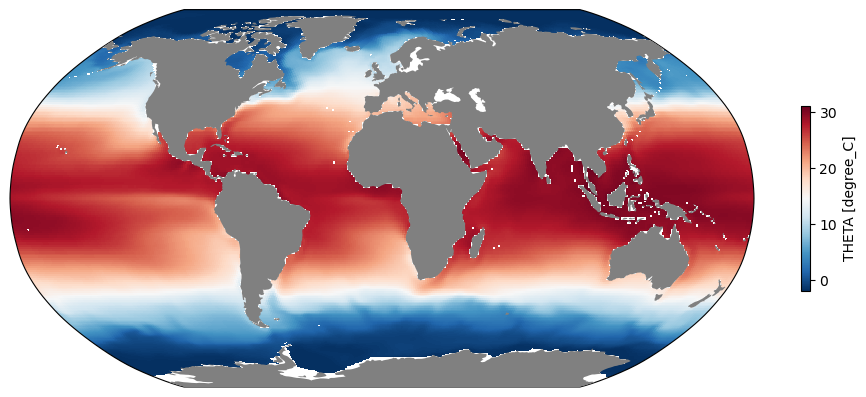

In [11]:
mapper(mean_sst, cmap='RdBu_r');

## Lazy evaluation and parallelism with dask

The computations above are executed locally by [dask](https://docs.dask.org/en/latest/), which builds a task graph and only reads/computes data when we call `.load()` (or make a plot). Because the work is chunked, dask can stream through the data without loading the whole dataset into memory at once, and it parallelizes naturally across the available CPU cores. The `%time` cell above illustrates this lazy-then-eager evaluation.

## Spatially-Integrated Heat Content Anomaly

Now let's do something harder. We will calculate the horizontally integrated heat content anomaly for the full 3D model domain. Because this subset covers a single year (2010), we define the anomaly relative to the **2010 annual mean**, which reveals the seasonal cycle of heat content as a function of depth.

In [12]:
# anomaly relative to the 2010 annual mean
theta_anom = ds.THETA - ds.THETA.mean(dim='time')
rho0 = 1029
cp = 3994
ohc = rho0 * cp * (theta_anom *
                   ds.rA *
                   ds.drF *
                   ds.hFacC).sum(dim=['tile', 'j', 'i'])
ohc.name = 'heat_content_anomaly'
ohc.attrs = {'long_name': 'Heat content anomaly', 'units': 'J'}
ohc

<xarray.DataArray 'heat_content_anomaly' (time: 12, k: 50)> Size: 2kB
dask.array<mul, shape=(12, 50), dtype=float32, chunksize=(1, 25), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 96B 2010-01-16T12:00:00 ... 2010-12-16T12:...
  * k        (k) int32 200B 0 1 2 3 4 5 6 7 8 9 ... 41 42 43 44 45 46 47 48 49
    Z        (k) float32 200B dask.array<chunksize=(50,), meta=np.ndarray>
Attributes:
    long_name:  Heat content anomaly
    units:      J

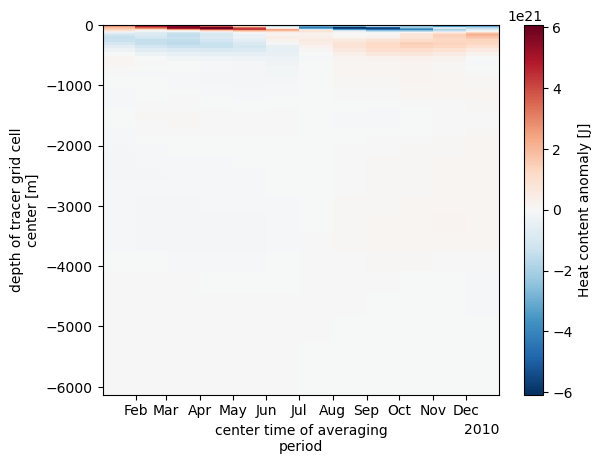

In [13]:
# actually load the data
ohc.load()
# put the depth coordinate back for plotting purposes
ohc.coords['Z'] = ds.Z
lim = float(abs(ohc).max())
ohc.swap_dims({'k': 'Z'}).transpose().plot(vmax=lim, vmin=-lim, cmap='RdBu_r')

The depth–time Hovmöller plot shows the **seasonal heat-content anomaly relative to the 2010 annual mean**: heat accumulates in the upper ocean during summer and is released in winter, with the signal concentrated in the upper few hundred meters.

## Spatial Derivatives: Heat Budget

As our final exercise, we will do something much more complicated. We will compute the time-mean convergence of vertically-integrated heat fluxes. This is hard for several reasons.

The first reason it is hard is because it involves variables located at different grid points.
Following MITgcm conventions, the dataset labels the tracer (center) point with the coordinates `j, i`, the u-velocity point as `j, i_g`, and the v-velocity point as `j_g, i`.
The horizontal advective heat flux variables are

    ADVx_TH    (time, k, tile, j, i_g) float32 dask.array<chunksize=(1, 50, 13, 90, 90)>
    ADVy_TH    (time, k, tile, j_g, i) float32 dask.array<chunksize=(1, 50, 13, 90, 90)>

Xarray won't allow us to add or multiply variables that have different dimensions, and xarray by itself doesn't understand how to transform from one grid position to another.

**That's why [xgcm](https://xgcm.readthedocs.io/en/latest/) was created.**

Xgcm allows us to create a `Grid` object, which understands how to interpolate and take differences in a way that is compatible with finite-volume models such as MITgcm. Xgcm also works with many other models, including ROMS, POP, MOM5/6, NEMO, etc.

A second reason this is hard is because of the complex topology connecting the different LLC tiles (faces). Fortunately xgcm also [supports this](https://xgcm.readthedocs.io/en/latest/grid_topology.html). The ECCOv4r4 native-grid files store the horizontal face dimension as `tile` (0–12, the standard 13-tile LLC layout), and they carry the [Comodo](https://web.archive.org/web/20160417032300/http://pycomodo.forge.imag.fr/norm.html) `axis` / `c_grid_axis_shift` attributes, so xgcm auto-detects the X/Y/Z axes — we only need to supply the tile connectivity.

In [14]:
import xgcm

# define the connectivity between LLC tiles (faces)
face_connections = {'tile':
                    {0: {'X':  ((12, 'Y', False), (3, 'X', False)),
                         'Y':  (None,             (1, 'Y', False))},
                     1: {'X':  ((11, 'Y', False), (4, 'X', False)),
                         'Y':  ((0, 'Y', False),  (2, 'Y', False))},
                     2: {'X':  ((10, 'Y', False), (5, 'X', False)),
                         'Y':  ((1, 'Y', False),  (6, 'X', False))},
                     3: {'X':  ((0, 'X', False),  (9, 'Y', False)),
                         'Y':  (None,             (4, 'Y', False))},
                     4: {'X':  ((1, 'X', False),  (8, 'Y', False)),
                         'Y':  ((3, 'Y', False),  (5, 'Y', False))},
                     5: {'X':  ((2, 'X', False),  (7, 'Y', False)),
                         'Y':  ((4, 'Y', False),  (6, 'Y', False))},
                     6: {'X':  ((2, 'Y', False),  (7, 'X', False)),
                         'Y':  ((5, 'Y', False),  (10, 'X', False))},
                     7: {'X':  ((6, 'X', False),  (8, 'X', False)),
                         'Y':  ((5, 'X', False),  (10, 'Y', False))},
                     8: {'X':  ((7, 'X', False),  (9, 'X', False)),
                         'Y':  ((4, 'X', False),  (11, 'Y', False))},
                     9: {'X':  ((8, 'X', False),  None),
                         'Y':  ((3, 'X', False),  (12, 'Y', False))},
                     10: {'X': ((6, 'Y', False),  (11, 'X', False)),
                          'Y': ((7, 'Y', False),  (2, 'X', False))},
                     11: {'X': ((10, 'X', False), (12, 'X', False)),
                          'Y': ((8, 'Y', False),  (1, 'X', False))},
                     12: {'X': ((11, 'X', False), None),
                          'Y': ((9, 'Y', False),  (0, 'X', False))}}}

# create the grid object
grid = xgcm.Grid(ds, padding='fill', face_connections=face_connections)
grid

<xgcm.Grid>
T Axis (not periodic, padding='fill'):
  * center   time
Z Axis (not periodic, padding='fill'):
  * center   k --> left
  * right    k_u --> center
  * left     k_l --> center
  * outer    k_p1 --> center
Y Axis (not periodic, padding='fill'):
  * center   j --> left
  * left     j_g --> center
X Axis (not periodic, padding='fill'):
  * center   i --> left
  * left     i_g --> center

Now we can use the `grid` object we created to take the divergence of a 2D vector.

In [15]:
# vertical integral and time mean of horizontal advective heat flux
advx_th_vint = ds.ADVx_TH.sum(dim='k').mean(dim='time')
advy_th_vint = ds.ADVy_TH.sum(dim='k').mean(dim='time')

# difference in the x and y directions
diff_ADV_th = grid.diff_2d_vector({'X': advx_th_vint, 'Y': advy_th_vint}, padding='fill')
# convergence
conv_ADV_th = -diff_ADV_th['X'] - diff_ADV_th['Y']
conv_ADV_th

<xarray.DataArray (tile: 13, j: 90, i: 90)> Size: 421kB
dask.array<sub, shape=(13, 90, 90), dtype=float32, chunksize=(1, 45, 45), chunktype=numpy.ndarray>
Coordinates:
  * tile     (tile) int32 52B 0 1 2 3 4 5 6 7 8 9 10 11 12
  * j        (j) int32 360B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
  * i        (i) int32 360B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
    XC       (tile, j, i) float32 421kB -111.6 -111.3 -110.9 ... -105.6 -111.9
    YC       (tile, j, i) float32 421kB -88.24 -88.38 -88.52 ... -88.08 -88.1
Attributes:
    units:                  degree_C m3 s-1
    coverage_content_type:  modelResult
    direction:              >0 increases potential temperature (THETA)

In [16]:
# vertical integral and time mean of horizontal diffusive heat flux
difx_th_vint = ds.DFxE_TH.sum(dim='k').mean(dim='time')
dify_th_vint = ds.DFyE_TH.sum(dim='k').mean(dim='time')

# difference in the x and y directions
diff_DIF_th = grid.diff_2d_vector({'X': difx_th_vint, 'Y': dify_th_vint}, padding='fill')
# convergence
conv_DIF_th = -diff_DIF_th['X'] - diff_DIF_th['Y']
conv_DIF_th

<xarray.DataArray (tile: 13, j: 90, i: 90)> Size: 421kB
dask.array<sub, shape=(13, 90, 90), dtype=float32, chunksize=(1, 45, 45), chunktype=numpy.ndarray>
Coordinates:
  * tile     (tile) int32 52B 0 1 2 3 4 5 6 7 8 9 10 11 12
  * j        (j) int32 360B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
  * i        (i) int32 360B 0 1 2 3 4 5 6 7 8 9 ... 81 82 83 84 85 86 87 88 89
    XC       (tile, j, i) float32 421kB -111.6 -111.3 -110.9 ... -105.6 -111.9
    YC       (tile, j, i) float32 421kB -88.24 -88.38 -88.52 ... -88.08 -88.1
Attributes:
    units:                  degree_C m3 s-1
    coverage_content_type:  modelResult
    direction:              >0 increases potential temperature (THETA)

In [17]:
# convert to Watts / m^2 and load
mean_adv_conv = rho0 * cp * (conv_ADV_th/ds.rA).fillna(0.).load()
mean_dif_conv = rho0 * cp * (conv_DIF_th/ds.rA).fillna(0.).load()

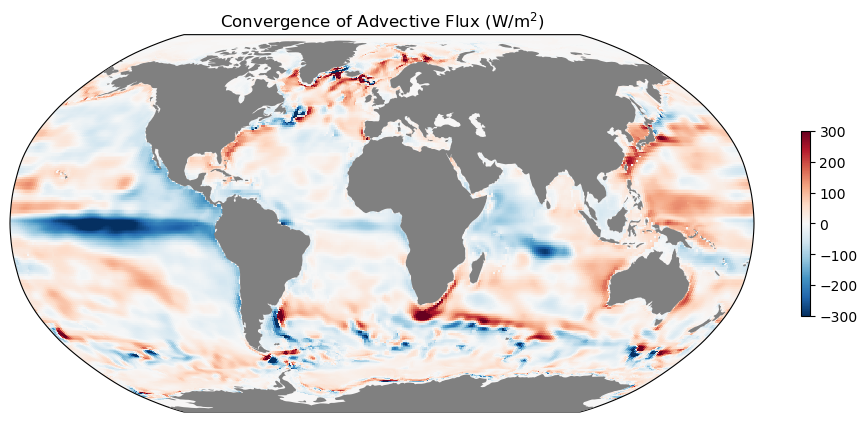

In [18]:
ax = mapper(mean_adv_conv, cmap='RdBu_r', vmax=300, vmin=-300);
ax.set_title(r'Convergence of Advective Flux (W/m$^2$)');

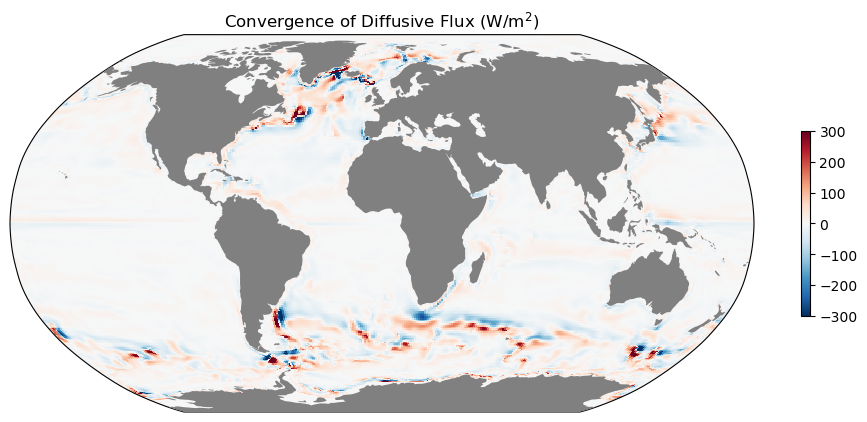

In [19]:
ax = mapper(mean_dif_conv, cmap='RdBu_r', vmax=300, vmin=-300)
ax.set_title(r'Convergence of Diffusive Flux (W/m$^2$)');

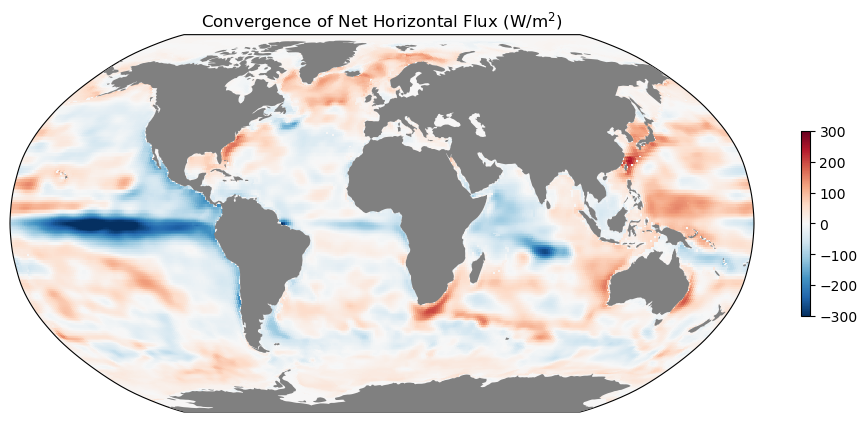

In [20]:
ax = mapper(mean_dif_conv + mean_adv_conv, cmap='RdBu_r', vmax=300, vmin=-300)
ax.set_title(r'Convergence of Net Horizontal Flux (W/m$^2$)');

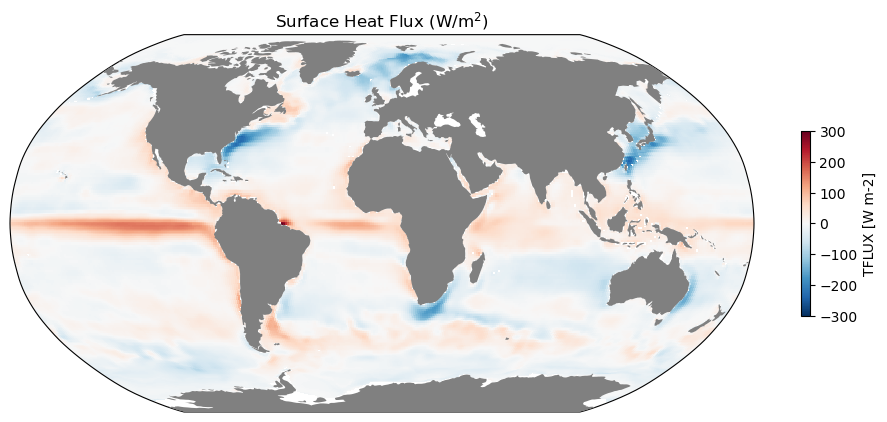

In [21]:
ax = mapper(ds.TFLUX.mean(dim='time').load(), cmap='RdBu_r', vmax=300, vmin=-300);
ax.set_title(r'Surface Heat Flux (W/m$^2$)');